# Flight delay — visual exploration

Charts for the 2015 US DOT flight data and the fitted pipeline. This notebook is
the *exploratory* companion to `benchmark_results.py`, which generates the fixed
figures that `docs/REPORT.md` embeds. Nothing here overwrites those.

**Run it with the project's own interpreter.** Select the kernel at
`.venv/Scripts/python.exe` (Python 3.11), never the system Python.
System Python is 3.14 and carries MLflow 3.8.1; a single query from it
silently migrates `mlflow.db` to a schema the pinned 2.19.0 then refuses to
open, taking all 14 tournament runs with it.

Everything below reads. Nothing writes to `mlflow.db`, `models/` or
`docs/benchmarks/`.


## Setup

This cell configures the Spark runtime itself &mdash; a Jupyter kernel does not
inherit `source ./env.sh`, so `JAVA_HOME` and friends are set here from the
project-local `.jdk/` and `.hadoop/` directories. It asserts Python 3.11 and
Java 17 before going any further, because both failures are confusing further
downstream: the wrong Java gives
`UnsupportedOperationException: getSubject is not supported`, and the wrong
Python can migrate `mlflow.db` out from under the pinned MLflow.

The palette is imported from `benchmark_results.py` rather than redeclared, so
these charts and the report figures cannot drift apart.


In [1]:
import os, sys, glob, json, subprocess

# repo root, whether the notebook is launched from here or from notebooks/
ROOT = os.path.abspath('..' if os.path.basename(os.getcwd()) == 'notebooks' else '.')
sys.path.insert(0, ROOT)
os.chdir(ROOT)

# ---------------------------------------------------------------------------
# Spark runtime. A Jupyter kernel does NOT inherit `source ./env.sh`, so the
# same values are set here. Without this the JVM launches on whatever JDK is on
# PATH and Spark dies with:
#     java.lang.UnsupportedOperationException: getSubject is not supported
# Spark 3.5 needs Java 17; Java 18+ removed the Subject API that Hadoop calls.
# Every path is project-local - nothing outside the repo is touched.
# ---------------------------------------------------------------------------
jdks = sorted(glob.glob(os.path.join(ROOT, '.jdk', 'jdk-*')))
if not jdks:
    raise SystemExit('No JDK under .jdk/ - see SETUP.md')

os.environ['JAVA_HOME']            = jdks[-1]
os.environ['HADOOP_HOME']          = os.path.join(ROOT, '.hadoop')
os.environ['SPARK_LOCAL_DIRS']     = os.path.join(ROOT, '.spark-tmp')
venv_python                        = os.path.join(ROOT, '.venv', 'Scripts', 'python.exe')
os.environ['PYSPARK_PYTHON']       = venv_python
os.environ['PYSPARK_DRIVER_PYTHON'] = venv_python
os.environ['PYTHONPATH']           = ROOT + os.pathsep + os.environ.get('PYTHONPATH', '')
os.environ['PYTHONUTF8']           = '1'
os.environ['PATH'] = os.pathsep.join([
    os.path.join(os.environ['JAVA_HOME'], 'bin'),
    os.path.join(os.environ['HADOOP_HOME'], 'bin'),
    os.environ['PATH'],
])

java_v = subprocess.run([os.path.join(os.environ['JAVA_HOME'], 'bin', 'java'), '-version'],
                        capture_output=True, text=True).stderr.splitlines()[0]
print('python     ', sys.version.split()[0], '  <- must be 3.11')
print('JAVA_HOME  ', os.environ['JAVA_HOME'])
print('java       ', java_v, '  <- must be 17')
assert sys.version_info[:2] == (3, 11), 'wrong kernel: select .venv/Scripts/python.exe'
assert '17.' in java_v, 'wrong JDK - Spark 3.5 needs Java 17'
# A JVM already running in this kernel is reused: pyspark caches the gateway on
# SparkContext._gateway for the life of the process, so a JAVA_HOME set now
# would be ignored. That is what makes a failed first attempt keep failing.
from pyspark import SparkContext as _SC
if getattr(_SC, '_gateway', None) is not None:
    raise SystemExit(
        'A JVM is already running in this kernel, started with the OLD JAVA_HOME.'
        'Re-running cells cannot fix it. Kernel -> Restart Kernel, then run this '
        'cell first, before any other.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# One house style, shared with the report figures, so these charts and the
# figures in docs/REPORT.md cannot drift apart.
from benchmark_results import SURFACE, INK, INK_2, GRID, SERIES, SEQ, style_axes
BLUE, ORANGE = SERIES

# benchmark_results.py is a headless script: it calls matplotlib.use('Agg') at
# import time because it only ever writes PNGs. Importing it inherits that
# backend, and Agg cannot draw into a notebook - plt.show() then warns
# "FigureCanvasAgg is non-interactive" and renders nothing. Switch back.
import matplotlib
try:
    get_ipython().run_line_magic('matplotlib', 'inline')      # normal Jupyter path
except Exception:
    try:                                                      # any other shell
        matplotlib.use('module://matplotlib_inline.backend_inline')
    except Exception:
        pass          # plain script: Agg is the right backend, leave it alone
print('backend    ', matplotlib.get_backend())

plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE,
    'savefig.facecolor': SURFACE, 'font.size': 10,
    'axes.edgecolor': GRID, 'axes.labelcolor': INK, 'text.color': INK,
    'xtick.color': INK, 'ytick.color': INK, 'figure.dpi': 110,
})
thousands = FuncFormatter(lambda v, _: f'{v:,.0f}')
print('palette    ', BLUE, ORANGE, '| surface', SURFACE)





python      3.11.15   <- must be 3.11
JAVA_HOME   d:\BigData\.jdk\jdk-17.0.20.1+1
java        openjdk version "17.0.20.1" 2026-08-18   <- must be 17
backend     inline
palette     #2a78d6 #eb6834 | surface #fcfcfb


In [2]:
from spark_session import build_spark, path

# Modest footprint: these are aggregations and samples, not a training run.
spark = build_spark('notebook-viz', cores='4', driver_memory='3g',
                    shuffle_partitions=16)
spark.sparkContext.setLogLevel('ERROR')

df = spark.read.parquet(path('data', 'parquet', 'flights_curated').replace('\\', '/'))
df.cache()
n_rows = df.count()
print(f'{n_rows:,} curated flights  ·  {len(df.columns)} columns')


5,704,000 curated flights  ·  29 columns


## 1 — What are we predicting?

`label_delay` is arrival delay in minutes. Negative means the flight landed early,
which is common: most flights are close to on time and the distribution has a long
right tail rather than a symmetric spread.


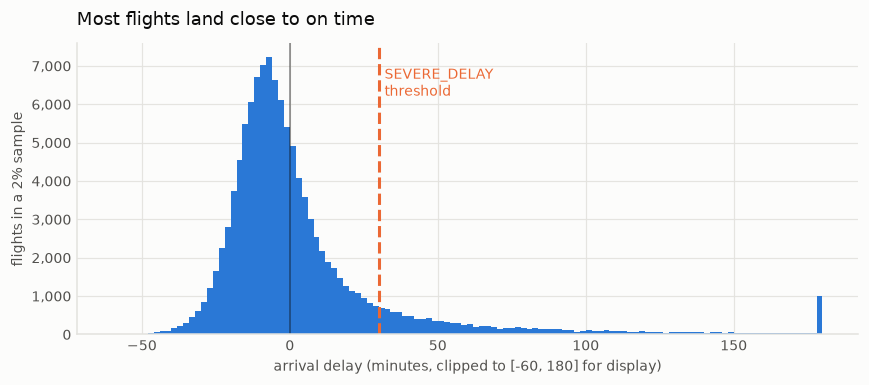

median -5 min · mean +4.5 min
landed early: 61.1%  ·  more than 30 min late: 11.1%


In [3]:
from pyspark.sql import functions as F

# 2% is ~114k rows — plenty for a shape, cheap to collect.
delay = (df.select('label_delay')
           .sample(False, 0.02, seed=42)
           .toPandas()['label_delay'])

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.hist(delay.clip(-60, 180), bins=120, color=BLUE, edgecolor='none')
ax.axvline(0, color=INK, lw=1, alpha=.5)
ax.axvline(30, color=ORANGE, lw=2, ls='--')
ax.text(32, ax.get_ylim()[1] * .82, 'SEVERE_DELAY\nthreshold', color=ORANGE, fontsize=9)
ax.yaxis.set_major_formatter(thousands)
style_axes(ax, 'arrival delay (minutes, clipped to [-60, 180] for display)',
           'flights in a 2% sample', 'Most flights land close to on time')
plt.tight_layout()
plt.show()

print(f"median {delay.median():+.0f} min · mean {delay.mean():+.1f} min")
print(f"landed early: {(delay < 0).mean():.1%}  ·  more than 30 min late: {(delay > 30).mean():.1%}")


## 2 — Why a straight line wins

This is the single most important picture in the project. Arrival delay is very
nearly a linear function of departure delay, which is why plain linear regression
beat both tree ensembles.


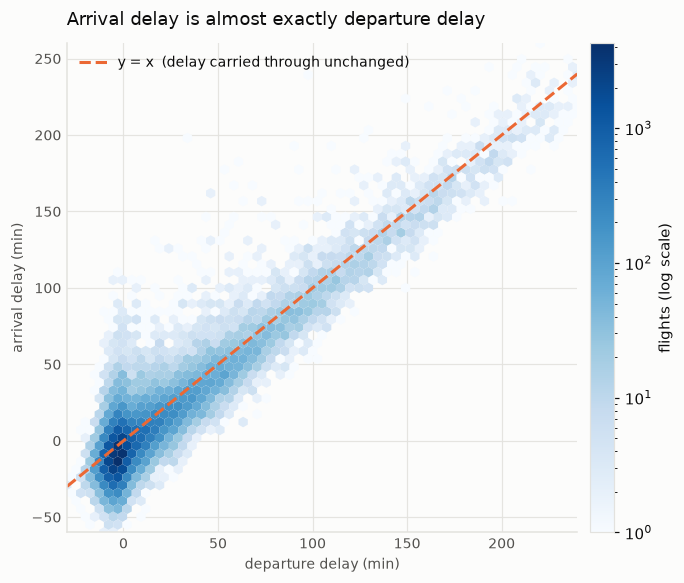

correlation = 0.9446   (computed over all 5,704,000 rows)


In [4]:
pair = (df.select('DEPARTURE_DELAY', 'label_delay')
          .sample(False, 0.01, seed=42)
          .toPandas())
pair = pair[(pair.DEPARTURE_DELAY.between(-30, 240)) & (pair.label_delay.between(-60, 260))]

fig, ax = plt.subplots(figsize=(6.4, 5.4))
hb = ax.hexbin(pair.DEPARTURE_DELAY, pair.label_delay, gridsize=55,
               bins='log', cmap='Blues', mincnt=1, linewidths=0)
lim = np.array([-30, 240])
ax.plot(lim, lim, color=ORANGE, lw=2, ls='--', label='y = x  (delay carried through unchanged)')
ax.set_xlim(-30, 240); ax.set_ylim(-60, 260)
cb = fig.colorbar(hb, ax=ax, pad=.02); cb.set_label('flights (log scale)')
cb.outline.set_edgecolor(GRID)
ax.legend(loc='upper left', frameon=False, fontsize=9)
style_axes(ax, 'departure delay (min)', 'arrival delay (min)',
           'Arrival delay is almost exactly departure delay')
plt.tight_layout(); plt.show()

corr = df.stat.corr('DEPARTURE_DELAY', 'label_delay')
print(f'correlation = {corr:.4f}   (computed over all {n_rows:,} rows)')


The cloud hugs `y = x`. A flight that leaves 40 minutes late lands roughly 40
minutes late — airlines recover only a few minutes en route. A straight line
models that *exactly*; a tree has to approximate it with a staircase of splits,
which is why it scores lower and costs twice the wall-clock time.


## 3 — The IQR fences, and why the raw column survives them

`OutlierIQRTruncator` clips `DEPARTURE_DELAY` to Tukey fences fitted on the
training split. Those fences are frozen inside the saved model, so we read them
from disk rather than recomputing.


Q1 -5   median -2   Q3 7   IQR 12
fences from the fitted model: [-23, 25]


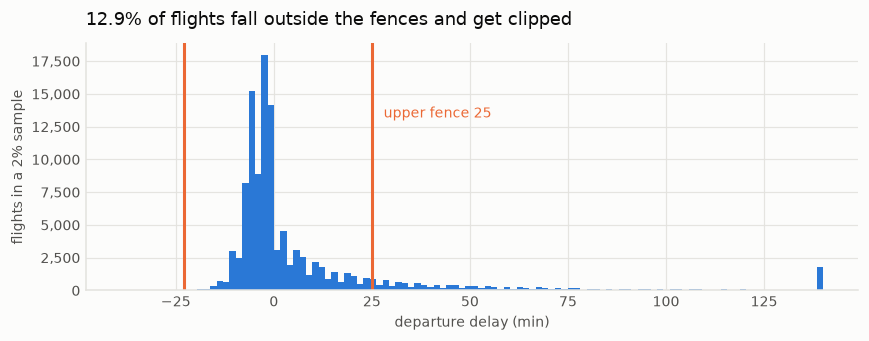

In [5]:
meta = json.load(open('models/best_pipeline/stages/'
                      '00_OutlierIQRTruncatorModel_4b053c8a9d72/metadata/part-00000'))
lo, hi = meta['paramMap']['lowerBounds'][0], meta['paramMap']['upperBounds'][0]
q1, med, q3 = df.approxQuantile('DEPARTURE_DELAY', [.25, .5, .75], .001)
print(f'Q1 {q1:.0f}   median {med:.0f}   Q3 {q3:.0f}   IQR {q3-q1:.0f}')
print(f'fences from the fitted model: [{lo:.0f}, {hi:.0f}]')

dep = (df.select('DEPARTURE_DELAY').sample(False, 0.02, seed=42)
         .toPandas()['DEPARTURE_DELAY'])
clipped_pct = ((dep < lo) | (dep > hi)).mean()

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.hist(dep.clip(-40, 140), bins=110, color=BLUE, edgecolor='none')
for x in (lo, hi):
    ax.axvline(x, color=ORANGE, lw=2)
ax.text(hi + 3, ax.get_ylim()[1] * .7, f'upper fence {hi:.0f}', color=ORANGE, fontsize=9)
ax.yaxis.set_major_formatter(thousands)
style_axes(ax, 'departure delay (min)', 'flights in a 2% sample',
           f'{clipped_pct:.1%} of flights fall outside the fences and get clipped')
plt.tight_layout(); plt.show()


Clipping helps the linear model, but it also destroys the signal in the tail —
and that tail is real information. The pipeline therefore keeps **both**:
`dep_delay_clip` *and* the untouched `DEPARTURE_DELAY`. Measured end to end,
clipped-only scored R² 0.390 and raw scored **0.937**.


## 4 — How skewed is each feature

Skewness is the third standardised moment, `g1 = E[(x-μ)³] / σ³`: zero for any
symmetric distribution, positive for a long right tail. It is the diagnostic
behind one concrete pipeline decision — which columns get
`SignedLog1pTransformer` and which are left alone — so it is worth looking at
rather than assuming.

Spark accumulates it in the same pass as the mean and variance, so the whole
profile is **one aggregation over all 5,704,000 rows**. That makes this the most
expensive cell in the notebook (about a minute at `local[4]`); everything above
samples instead.

Three of the columns profiled here are not in the curated parquet: the haversine
features are built inside the pipeline, so the same transformer rebuilds them.
The clipped and logged views are reconstructed with the fences *frozen in the
fitted model*, not refitted here, so the "after" numbers are the ones the model
actually saw.


In [6]:
from pyspark.sql import functions as F
from custom_transformers import HaversineTransformer
from mllib_pipeline import CLIP_COLS, CLIP_OUT, LOG_COLS, LOG_OUT

# GC_DISTANCE_MI / ROUTE_DETOUR / SCHEDULE_SPEED_MPH are pipeline outputs, not
# stored columns. HaversineTransformer is a pair of pandas_udfs, so rebuilding
# them stays a vectorised single pass rather than a per-row Python call.
feat = HaversineTransformer().transform(df)

# Fences from the saved model, exactly as section 3 read them - refitting them
# on the full data would describe a different clip than the one in the model.
iqr = json.load(open('models/best_pipeline/stages/'
                     '00_OutlierIQRTruncatorModel_4b053c8a9d72/metadata/part-00000'))
fences = dict(zip(iqr['paramMap']['inputCols'],
                  zip(iqr['paramMap']['lowerBounds'], iqr['paramMap']['upperBounds'])))


def clipped(col):
    lo_, hi_ = fences[col]
    return F.least(F.greatest(F.col(col).cast('double'), F.lit(lo_)), F.lit(hi_))


def signed_log1p(col):                      # what SignedLog1pTransformer applies
    return F.signum(F.col(col)) * F.log1p(F.abs(F.col(col)))


for src, out in zip(CLIP_COLS, CLIP_OUT):
    feat = feat.withColumn(out, clipped(src))
for src, out in zip(LOG_COLS, LOG_OUT):
    feat = feat.withColumn(out, signed_log1p(src))

# DEST_LAT/DEST_LON are omitted: every origin is some flight's destination, so
# their marginals match ORIGIN_LAT/ORIGIN_LON to three decimals.
RAW_NUMERIC = ['label_delay', 'DEPARTURE_DELAY', 'TAXI_OUT', 'DISTANCE',
               'SCHEDULED_TIME', 'GC_DISTANCE_MI', 'ROUTE_DETOUR',
               'SCHEDULE_SPEED_MPH', 'SCHED_DEP_MIN', 'SCHED_ARR_MIN',
               'WHEELS_OFF_MIN', 'ORIGIN_LAT', 'ORIGIN_LON', 'DAY']
PROFILED = RAW_NUMERIC + CLIP_OUT + LOG_OUT

aggs = []
for c in PROFILED:
    aggs += [F.skewness(c).alias(f'{c}|skew'), F.kurtosis(c).alias(f'{c}|kurt'),
             F.mean(c).alias(f'{c}|mean'), F.stddev(c).alias(f'{c}|sd'),
             F.expr(f'percentile_approx({c}, 0.5, 1000)').alias(f'{c}|median')]
row = feat.agg(*aggs).first().asDict()

skew = pd.DataFrame(
    [{'feature': c, **{k: float(row[f'{c}|{k}'])
                       for k in ('skew', 'kurt', 'mean', 'sd', 'median')}}
     for c in PROFILED]).set_index('feature')

# Pearson's second coefficient, 3(mean - median)/sd. It uses no third power, so
# it is a cross-check that a moment-based figure describes the bulk of a column
# and not a handful of extreme rows.
skew['pearson2'] = 3 * (skew['mean'] - skew['median']) / skew['sd']
print(skew.round(3).to_string())

                      skew      kurt     mean       sd   median  pearson2
feature                                                                  
label_delay          6.498    97.581    4.411   39.272   -5.000     0.719
DEPARTURE_DELAY      7.595   123.349    9.298   36.890   -2.000     0.919
TAXI_OUT             3.460    23.927   16.070    8.884   14.000     0.699
DISTANCE             1.416     2.218  825.048  608.822  651.000     0.858
SCHEDULED_TIME       1.339     1.937  141.973   75.334  123.000     0.756
GC_DISTANCE_MI       1.407     2.181  823.926  606.689  650.174     0.859
ROUTE_DETOUR        83.475  7100.660    1.001    0.031    1.001    -0.001
SCHEDULE_SPEED_MPH  -0.332    -0.314  315.013   82.296  322.340    -0.267
SCHED_DEP_MIN        0.058    -1.017  808.042  290.854  805.000     0.031
SCHED_ARR_MIN       -0.284    -0.489  907.539  304.381  919.000    -0.113
WHEELS_OFF_MIN      -0.016    -0.901  825.590  299.091  823.000     0.026
ORIGIN_LAT          -0.049     1.424  

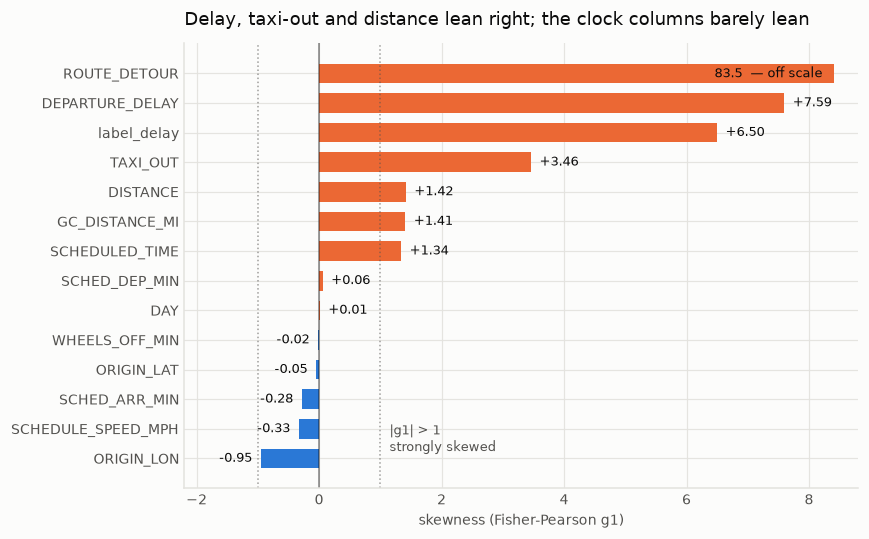

strongly skewed (|g1| > 1): SCHEDULED_TIME, GC_DISTANCE_MI, DISTANCE, TAXI_OUT, label_delay, DEPARTURE_DELAY, ROUTE_DETOUR


In [7]:
bars = skew.loc[RAW_NUMERIC].sort_values('skew')

# ROUTE_DETOUR (+83.5) is two orders of magnitude past the rest; drawn to scale
# every other bar becomes a hairline. The axis stops at CAP and that one bar is
# drawn to the cap with its true value printed inside it.
CAP = 8.4
fig, ax = plt.subplots(figsize=(8, 5))
y = np.arange(len(bars))
colors = [ORANGE if v > 0 else BLUE for v in bars['skew']]
ax.barh(y, np.clip(bars['skew'], -CAP, CAP), color=colors, height=.66)

for x in (-1, 1):
    ax.axvline(x, color=INK_2, lw=1, ls=':', alpha=.55)
ax.axvline(0, color=INK, lw=1, alpha=.5)
ax.text(1.15, .1, '|g1| > 1\nstrongly skewed',
        color=INK_2, fontsize=8.5, va='bottom')

for i, v in enumerate(bars['skew']):
    if abs(v) > CAP:
        ax.text(CAP - .18, i, f'{v:,.1f}  — off scale', va='center',
                ha='right', fontsize=8.5, color=INK)
    else:
        ax.text(v + (.14 if v >= 0 else -.14), i, f'{v:+.2f}', va='center',
                ha='left' if v >= 0 else 'right', fontsize=8.5, color=INK)

ax.set_yticks(y)
ax.set_yticklabels(bars.index, fontsize=8.5)
ax.set_xlim(-2.2, CAP + .4)
ax.grid(axis='y', visible=False)
style_axes(ax, 'skewness (Fisher-Pearson g1)', '',
           'Delay, taxi-out and distance lean right; the clock columns barely lean')
plt.tight_layout(); plt.show()

print('strongly skewed (|g1| > 1):',
      ', '.join(bars[bars['skew'].abs() > 1].index))

The usual reading of `g1`: under 0.5 is near enough symmetric, 0.5 to 1 is
moderate, past 1 is strong.

- **`DEPARTURE_DELAY` (+7.60) and `label_delay` (+6.50)** are the extreme pair,
  with kurtosis 123 and 98 against 0 for a normal. Almost every flight sits in a
  tight clump near zero and a thin tail runs out to several hundred minutes —
  the shape section 1 drew.
- **`DISTANCE` (+1.42), `GC_DISTANCE_MI` (+1.41), `SCHEDULED_TIME` (+1.34)** are
  the ordinary right skew of a fleet flying many short hops and a few
  transcontinental legs. These are exactly the three columns `LOG_COLS` names.
- **`ROUTE_DETOUR` (+83.5, kurtosis 7,101)** is a different animal, and the
  `pearson2` column gives it away: +83.5 by moments, **−0.001** by the median.
  Its standard deviation is 0.031 — published distance is within a fraction of a
  percent of the geodesic for nearly every flight — so the moment figure is
  describing a handful of dog-leg routings, not the shape of the column. Do not
  "fix" it: the log of a near-constant is still a near-constant, and
  `StandardScaler` divides it to unit spread anyway, with the constant offset
  absorbed by the model intercept.
- **`ORIGIN_LON` (−0.95)** is skewed for a reason no transform helps: US traffic
  is bimodal in longitude, clustered on two coasts.
- **`SCHED_DEP_MIN`, `WHEELS_OFF_MIN`, `DAY` (≈ 0)** are symmetric, and their
  *negative* kurtosis (−1.02, −0.90, −1.19) says flat rather than normal —
  departures spread across the flying day, dates across the month. Symmetry
  alone never implies normality.


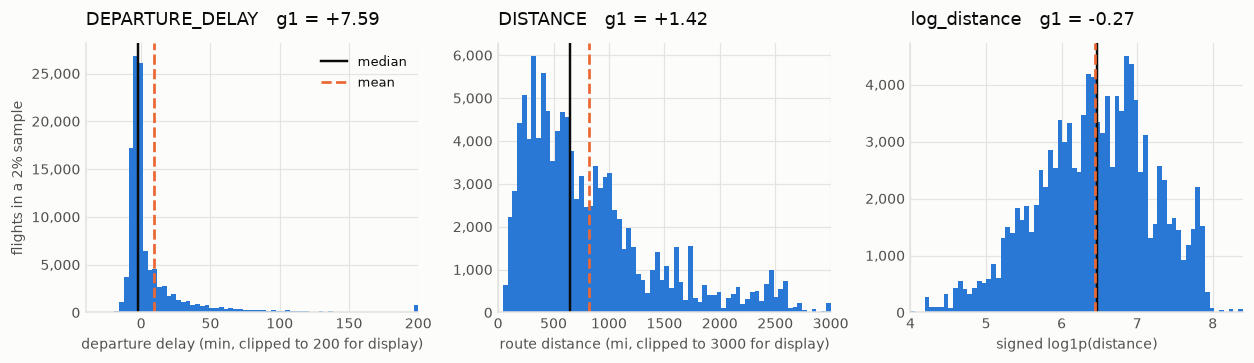

mean minus median - the visible gap in each panel:
  DEPARTURE_DELAY    +11.30   (sd 36.89)
  DISTANCE          +174.05   (sd 608.82)
  log_distance        -0.03   (sd 0.76)


In [8]:
# 2% sample - shape only; the numbers above already came from the full data.
samp = (feat.select('DEPARTURE_DELAY', 'DISTANCE', 'log_distance')
            .sample(False, 0.02, seed=42).toPandas())

# The tails run far past these limits, so the last bin of the first two
# panels is a pile-up of everything beyond it - that spike is the clip, not
# the data. It is the tail that the skew number is measuring.
panels = [('DEPARTURE_DELAY', 'departure delay (min, clipped to 200 for display)',
           (-40, 200)),
          ('DISTANCE', 'route distance (mi, clipped to 3000 for display)',
           (0, 3000)),
          ('log_distance', 'signed log1p(distance)', (4.0, 8.4))]

fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.4))
for ax, (col, xlabel, xlim) in zip(axes, panels):
    v = samp[col]
    ax.hist(v.clip(*xlim), bins=70, range=xlim, color=BLUE, edgecolor='none')
    ax.axvline(v.median(), color=INK, lw=1.6, label='median')
    ax.axvline(v.mean(), color=ORANGE, lw=1.8, ls='--', label='mean')
    ax.set_xlim(*xlim)
    ax.yaxis.set_major_formatter(thousands)
    style_axes(ax, xlabel,
               'flights in a 2% sample' if col == 'DEPARTURE_DELAY' else '',
               f'{col}   g1 = {skew.loc[col, "skew"]:+.2f}')
axes[0].legend(frameon=False, fontsize=8.5, loc='upper right')
plt.tight_layout(); plt.show()

print('mean minus median - the visible gap in each panel:')
for col, *_ in panels:
    r = skew.loc[col]
    print(f'  {col:<16} {r["mean"] - r["median"]:+8.2f}   (sd {r["sd"]:.2f})')

Right skew is exactly this: the mean dragged past the median by the tail. The
third panel is the same distance column after `sign(x)·log(1+|x|)` — the tail is
pulled in and the two lines land on top of each other.

Section 3 showed the other lever, Tukey clipping. Both are in the pipeline, on
different columns, so here is what each one actually does to the shape:


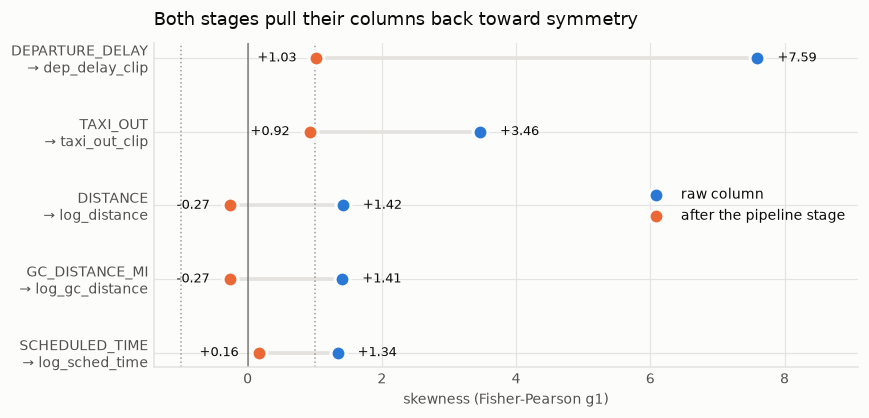

In [9]:
moves = list(zip(CLIP_COLS, CLIP_OUT)) + list(zip(LOG_COLS, LOG_OUT))
moves.sort(key=lambda pair: abs(skew.loc[pair[0], 'skew']))

before = np.array([skew.loc[s, 'skew'] for s, _ in moves])
after = np.array([skew.loc[o, 'skew'] for _, o in moves])

fig, ax = plt.subplots(figsize=(8, 3.9))
y = np.arange(len(moves))
ax.hlines(y, before, after, color=GRID, lw=2.4, zorder=1)
ax.scatter(before, y, s=95, color=BLUE, zorder=3, edgecolor=SURFACE, linewidth=2,
           label='raw column')
ax.scatter(after, y, s=95, color=ORANGE, zorder=3, edgecolor=SURFACE, linewidth=2,
           label='after the pipeline stage')
ax.axvline(0, color=INK, lw=1, alpha=.5)
for x in (-1, 1):                          # same |g1| > 1 band as the bar chart
    ax.axvline(x, color=INK_2, lw=1, ls=':', alpha=.55)

for i, (b, a) in enumerate(zip(before, after)):
    ax.text(b + .3, i, f'{b:+.2f}', va='center', fontsize=8.5, color=INK)
    ax.text(a - .3, i, f'{a:+.2f}', va='center', ha='right', fontsize=8.5, color=INK)

ax.set_yticks(y)
ax.set_yticklabels([f'{s}\n→ {o}' for s, o in moves], fontsize=8)
ax.set_xlim(-1.4, before.max() + 1.5)
ax.grid(axis='y', visible=False)
ax.legend(frameon=False, fontsize=9, loc='center right')
style_axes(ax, 'skewness (Fisher-Pearson g1)', '',
           'Both stages pull their columns back toward symmetry')
plt.tight_layout(); plt.show()

Both stages do what they advertise: the log pulls the three distance columns
from about +1.4 to roughly zero, and the Tukey clip takes `DEPARTURE_DELAY` from
+7.60 down to +1.03.

**And this is where skewness stops being the thing to optimise.** Symmetry is
not the objective; prediction is. Measured end to end on a 2% sample with linear
regression:

| what the model sees for departure delay | R² |
|---|---|
| `dep_delay_clip` only | 0.390 |
| signed log only | 0.409 |
| clip + log | 0.409 |
| **raw `DEPARTURE_DELAY`** | **0.937** |

Arrival delay is nearly linear in departure delay (corr 0.947, slope ≈ 1), and
that line *is* the skew — the same long tail in both columns, in step. Clipping
folds 12.8% of flights, which average +72.9 min of arrival delay, onto one
value; the log bends the line. The symmetric view is prettier and much less
useful.

So the pipeline keeps `dep_delay_clip` **and** the raw column, and drops the log
view of departure delay entirely (it earned +0.0001). Worth remembering that
least squares assumes nothing about the marginal distribution of a predictor —
only about the residuals. A skewed feature is not a violation to be corrected;
it is a fact to be checked against the metric.


## 5 — Where delay comes from

Two categorical cuts, aggregated in Spark and collected small.


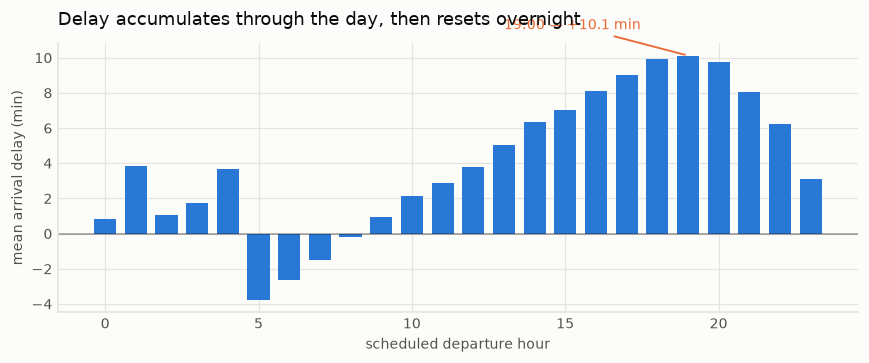

In [10]:
by_hour = (df.groupBy('DEP_HOUR')
             .agg(F.avg('label_delay').alias('avg'), F.count('*').alias('n'))
             .orderBy('DEP_HOUR').toPandas())

fig, ax = plt.subplots(figsize=(8, 3.4))
ax.bar(by_hour.DEP_HOUR, by_hour.avg, color=BLUE, width=.72)
ax.axhline(0, color=INK, lw=1, alpha=.4)
peak = by_hour.loc[by_hour.avg.idxmax()]
ax.annotate(f"{int(peak.DEP_HOUR):02d}:00 — {peak.avg:+.1f} min",
            xy=(peak.DEP_HOUR, peak.avg), xytext=(peak.DEP_HOUR - 6, peak.avg + 1.5),
            color=ORANGE, fontsize=9,
            arrowprops=dict(arrowstyle='-', color=ORANGE, lw=1.2))
style_axes(ax, 'scheduled departure hour', 'mean arrival delay (min)',
           'Delay accumulates through the day, then resets overnight')
plt.tight_layout(); plt.show()


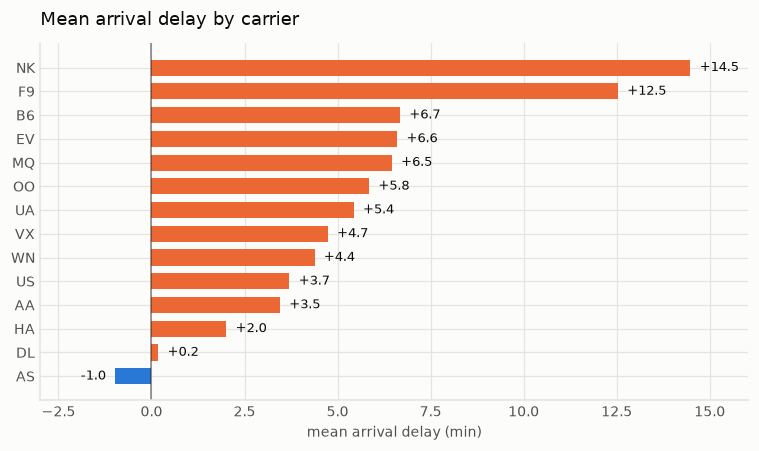

In [11]:
by_air = (df.groupBy('AIRLINE')
            .agg(F.avg('label_delay').alias('avg'), F.count('*').alias('n'))
            .orderBy('avg').toPandas())

fig, ax = plt.subplots(figsize=(7, 4.2))
colors = [ORANGE if v > 0 else BLUE for v in by_air.avg]
ax.barh(by_air.AIRLINE, by_air.avg, color=colors, height=.68)
ax.axvline(0, color=INK, lw=1, alpha=.5)

# Headroom on both sides, so an end label never lands on the tick labels
# (the one negative carrier) or on the frame (the longest bar).
low, high = min(by_air.avg.min(), 0), by_air.avg.max()
span = high - low
ax.set_xlim(low - span * .13, high + span * .10)

for y, v in enumerate(by_air.avg):
    ax.text(v + (.25 if v >= 0 else -.25), y, f'{v:+.1f}',
            va='center', ha='left' if v >= 0 else 'right', fontsize=8.5, color=INK)
style_axes(ax, 'mean arrival delay (min)', '', 'Mean arrival delay by carrier')
plt.tight_layout(); plt.show()


## 6 — What target encoding learned

`TargetEncoder` replaced 4,627 route strings with one number each. The learned
map is stored inside the saved model as a JSON parameter, so it can be read
without Spark.


4,627 routes · prior 4.417 min · smoothing m = 20


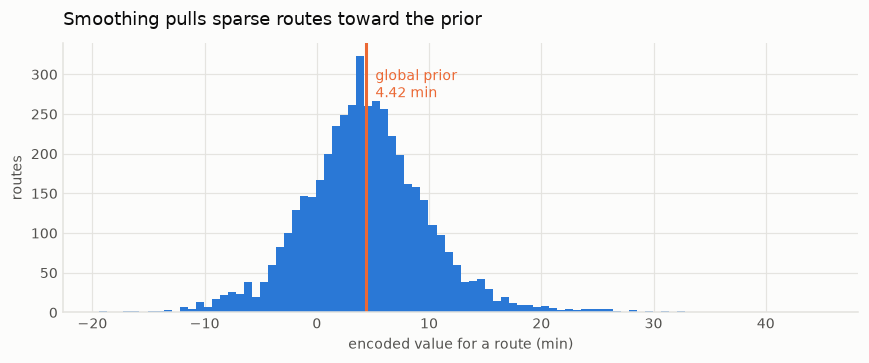


worst five routes
LGA-LIT    56.24
ASE-DFW    39.75
JFK-EGE    38.13
FAI-ORD    35.45
LIT-LGA    33.10

best five routes
ANC-KOA   -19.38
KOA-SAN   -19.02
CNY-SLC   -17.79
PDX-KOA   -16.76
HNL-BLI   -16.72


In [12]:
te = json.load(open('models/best_pipeline/stages/'
                    '04_TargetEncoderModel_d6478c56cb1d/metadata/part-00000'))
prior = te['paramMap']['prior']
m_smooth = te['paramMap']['smoothing']
mapping = json.loads(te['paramMap']['mappingJson'])
routes = pd.Series(mapping['ROUTE'])
print(f'{len(routes):,} routes · prior {prior:.3f} min · smoothing m = {m_smooth:.0f}')

fig, ax = plt.subplots(figsize=(8, 3.4))
ax.hist(routes.clip(-20, 45), bins=90, color=BLUE, edgecolor='none')
ax.axvline(prior, color=ORANGE, lw=2)
ax.text(prior + .8, ax.get_ylim()[1] * .8,
        f'global prior\n{prior:.2f} min', color=ORANGE, fontsize=9)
style_axes(ax, 'encoded value for a route (min)', 'routes',
           'Smoothing pulls sparse routes toward the prior')
plt.tight_layout(); plt.show()

print('\nworst five routes'); print(routes.nlargest(5).round(2).to_string())
print('\nbest five routes');  print(routes.nsmallest(5).round(2).to_string())


## 7 — What PCA kept, and what it cost

Ten components out of an 80-dimensional feature space.


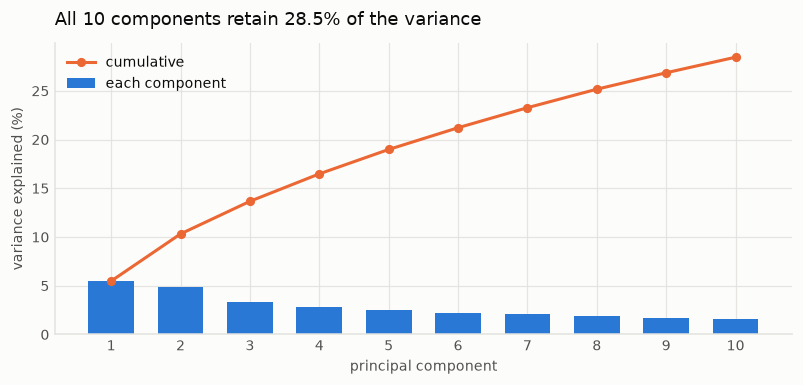

retained 28.5%  ·  discarded 71.5%


In [13]:
ev = json.load(open('docs/benchmarks/pca_explained_variance.json'))
cum = np.cumsum(ev)

fig, ax = plt.subplots(figsize=(7.4, 3.6))
ax.bar(range(1, len(ev) + 1), [v * 100 for v in ev], color=BLUE, width=.66,
       label='each component')
ax.plot(range(1, len(ev) + 1), cum * 100, color=ORANGE, lw=2, marker='o',
        markersize=5, label='cumulative')
ax.set_xticks(range(1, len(ev) + 1))
ax.legend(frameon=False, fontsize=9, loc='upper left')
style_axes(ax, 'principal component', 'variance explained (%)',
           f'All 10 components retain {cum[-1]*100:.1f}% of the variance')
plt.tight_layout(); plt.show()

print(f'retained {cum[-1]*100:.1f}%  ·  discarded {(1-cum[-1])*100:.1f}%')


The feature space is mostly one-hot indicators, which are near-orthogonal by
construction — there is little redundancy for PCA to exploit, so any ten
directions must throw most of the signal away. Linear regression falls from
R² 0.9289 to 0.7034 through `PCA(k=10)`.


## 8 — The tournament, read back from MLflow

Read-only. `search_runs` never writes; the schema-migration trap only bites when
a *different* MLflow version opens the file, which is what the kernel warning at
the top is about.


In [14]:
import mlflow
from mlflow.tracking import MlflowClient
from spark_session import TRACKING_URI

mlflow.set_tracking_uri(TRACKING_URI)
client = MlflowClient()
exp = client.get_experiment_by_name('flight-delay-mllib')

runs = {}
for r in client.search_runs([exp.experiment_id], max_results=1000,
                            order_by=['attributes.start_time ASC']):
    name = r.data.tags.get('mlflow.runName', '')
    if '__' in name and r.info.status == 'FINISHED' and r.data.metrics:
        runs[name] = r          # last write wins -> most recent run per arm

rows = []
for name, r in runs.items():
    model, arm = name.rsplit('__', 1)
    rows.append({'model': model, 'arm': arm,
                 'r2': r.data.metrics.get('r2'),
                 'auc': r.data.metrics.get('areaUnderROC'),
                 'seconds': r.data.metrics.get('train_seconds')})
res = pd.DataFrame(rows)
print(f'{len(res)} arms')
res.sort_values(['r2', 'auc'], ascending=False).round(4)


2026/09/05 22:20:34 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/09/05 22:20:34 INFO mlflow.store.db.utils: Updating database tables
INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
INFO  [alembic.runtime.migration] Will assume non-transactional DDL.
INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
INFO  [alembic.runtime.migration] Will assume non-transactional DDL.


14 arms


,model,arm,r2,auc,seconds
1,linear_regression,nopca,0.9289,NaN,1110.6854
9,gbt_regressor,nopca,0.8938,NaN,2324.7834
5,random_forest_regressor,nopca,0.8731,NaN,1881.1020
4,random_forest_regressor,pca,0.8558,NaN,1730.8326
8,gbt_regressor,pca,0.8513,NaN,2261.9974
0,linear_regression,pca,0.7034,NaN,1141.8740
11,glm_poisson_log,pca,0.5309,NaN,2149.3105
12,glm_poisson_log,nopca,-0.0357,NaN,2073.0641
13,gbt_classifier,nopca,NaN,0.9817,2336.1679
3,linear_svc,nopca,NaN,0.9806,959.2946


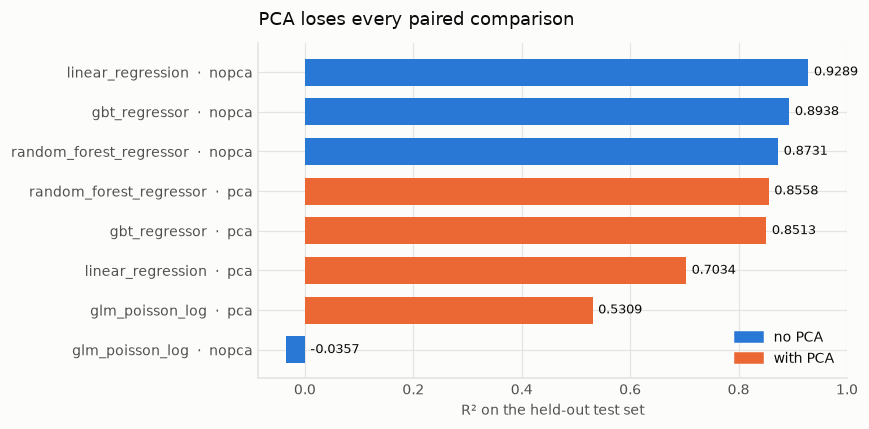

In [15]:
reg = res.dropna(subset=['r2']).sort_values('r2')

fig, ax = plt.subplots(figsize=(8, 4))
y = np.arange(len(reg))
colors = [ORANGE if a == 'pca' else BLUE for a in reg.arm]
ax.barh(y, reg.r2, color=colors, height=.68)
ax.set_yticks(y); ax.set_yticklabels([f'{m}  ·  {a}' for m, a in zip(reg.model, reg.arm)],
                                     fontsize=8.5)
for i, v in enumerate(reg.r2):
    ax.text(v + .01 if v > 0 else .01, i, f'{v:.4f}', va='center', fontsize=8.5, color=INK)
handles = [plt.Rectangle((0, 0), 1, 1, color=BLUE), plt.Rectangle((0, 0), 1, 1, color=ORANGE)]
ax.legend(handles, ['no PCA', 'with PCA'], frameon=False, fontsize=9, loc='lower right')
ax.set_xlim(min(0, reg.r2.min()) - .05, 1.0)
style_axes(ax, 'R² on the held-out test set', '', 'PCA loses every paired comparison')
plt.tight_layout(); plt.show()


In [16]:
paired = (res.dropna(subset=['r2'])
            .pivot(index='model', columns='arm', values='r2')
            .dropna())
paired['cost of PCA'] = paired['pca'] - paired['nopca']
paired.round(4).sort_values('cost of PCA')


arm,nopca,pca,cost of PCA
model,,,
linear_regression,0.9289,0.7034,-0.2255
gbt_regressor,0.8938,0.8513,-0.0425
random_forest_regressor,0.8731,0.8558,-0.0174
glm_poisson_log,-0.0357,0.5309,0.5665


## 9 — Cost against quality

When two models are indistinguishable on quality, the cheaper one should win.
That is the argument for `LinearSVC` on the classification task.


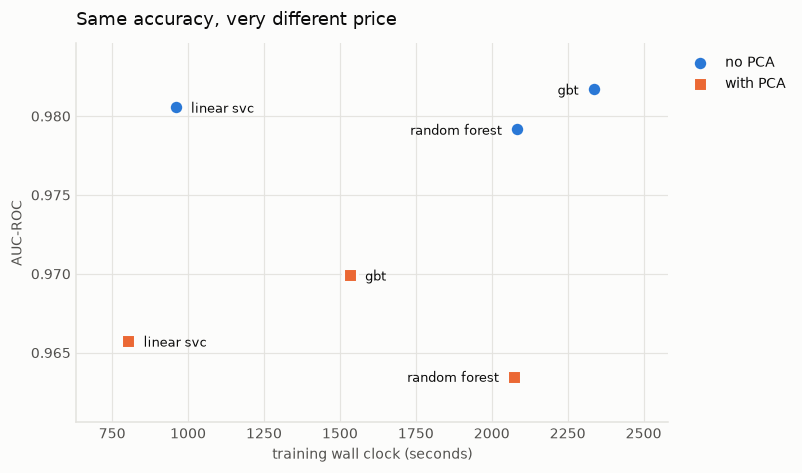

In [17]:
clf = res.dropna(subset=['auc'])

fig, ax = plt.subplots(figsize=(7.4, 4.4))
for arm, colour, mark in (('nopca', BLUE, 'o'), ('pca', ORANGE, 's')):
    sub = clf[clf.arm == arm]
    ax.scatter(sub.seconds, sub.auc, s=90, color=colour, marker=mark,
               label='no PCA' if arm == 'nopca' else 'with PCA', zorder=3,
               edgecolor=SURFACE, linewidth=2)

# Padding on every side so no annotation is clipped by the frame.
xpad = (clf.seconds.max() - clf.seconds.min()) * .16
ypad = (clf.auc.max() - clf.auc.min()) * .16
ax.set_xlim(clf.seconds.min() - xpad * .7, clf.seconds.max() + xpad)
ax.set_ylim(clf.auc.min() - ypad, clf.auc.max() + ypad)

# Label left-hand points to their right and right-hand points to their left,
# so nothing runs off the edge.
mid = clf.seconds.median()
for _, r in clf.iterrows():
    to_right = r.seconds < mid
    ax.annotate(r.model.replace('_classifier', '').replace('_', ' '),
                (r.seconds, r.auc), textcoords='offset points',
                xytext=(10 if to_right else -10, -3.5),
                ha='left' if to_right else 'right', fontsize=8.5, color=INK)

# Legend outside the plot area: every interior corner already holds a point.
ax.legend(frameon=False, fontsize=9, loc='upper left', bbox_to_anchor=(1.01, 1.0))
style_axes(ax, 'training wall clock (seconds)', 'AUC-ROC',
           'Same accuracy, very different price')
plt.tight_layout(); plt.show()


## Note on residuals

There is deliberately no residual plot here. Reproducing the held-out test set
means calling `mllib_pipeline.make_split()` **at the same core count as the
tournament** — `randomSplit` draws independently per input partition, and a
Parquet read makes one partition per core, so the same seed gives a different
split on a different `local[n]`: 16 cores yields 4,564,168 training rows, 8
yields 4,563,188, 4 yields 4,562,867.

Getting that wrong silently plots training rows as held-out. `benchmark_results.py`
handles it properly and checks the reconstructed row count against the run's
logged `test_rows` before drawing, so use `docs/benchmarks/residuals.png`.


In [18]:
spark.stop()
print('Spark stopped. Nothing was written to mlflow.db, models/ or docs/benchmarks/.')


Spark stopped. Nothing was written to mlflow.db, models/ or docs/benchmarks/.
